In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import os 
import seaborn as sns 
os.chdir(R"D:\AI\Elvorix Diploma\2. Machine Learning\2. Day 2")
df = pd.read_excel("Vehicle Price.xlsx")
df.head()

,name,description,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


In [2]:
# Show duplicated data 
print("The Summation of Duplicated Data ==> ", df.duplicated().sum())
#drop the duplicated data 
df.drop_duplicates(inplace=True)
print("The data after drop duplicated data are ==> ",df.duplicated().sum())
print("======="*10)
print("The Data Information are : ")
print("======="*10)
df.info()

The Summation of Duplicated Data ==>  24
The data after drop duplicated data are ==>  0
The Data Information are : 
<class 'pandas.DataFrame'>
Index: 978 entries, 0 to 1001
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            978 non-null    str    
 1   description     926 non-null    str    
 2   make            978 non-null    str    
 3   model           978 non-null    object 
 4   year            978 non-null    int64  
 5   price           955 non-null    float64
 6   engine          976 non-null    str    
 7   cylinders       875 non-null    float64
 8   fuel            971 non-null    str    
 9   mileage         946 non-null    float64
 10  transmission    976 non-null    str    
 11  trim            977 non-null    str    
 12  body            975 non-null    str    
 13  doors           971 non-null    float64
 14  exterior_color  973 non-null    str    
 15  interior_color  940 non-

In [3]:
#Show the Null Values 
print("The Percentage of Null Data :\n ",df.isnull().sum().sort_values(ascending=False)*100/(len(df)))
print("======="*10)
print("The Values count for Null Values are : ")
df.isnull().sum().sort_values(ascending=False)

The Percentage of Null Data :
  cylinders         10.531697
description        5.316973
interior_color     3.885481
mileage            3.271984
price              2.351738
fuel               0.715746
doors              0.715746
exterior_color     0.511247
body               0.306748
engine             0.204499
transmission       0.204499
trim               0.102249
name               0.000000
model              0.000000
make               0.000000
year               0.000000
drivetrain         0.000000
dtype: float64
The Values count for Null Values are : 


cylinders         103
description        52
interior_color     38
mileage            32
price              23
fuel                7
doors               7
exterior_color      5
body                3
engine              2
transmission        2
trim                1
name                0
model               0
make                0
year                0
drivetrain          0
dtype: int64

# Create Figure Plot

In [4]:
def plot_hist_box(column_data,column_name=None):
    if column_name is None : column_name = column_data.name 
    plt.figure(figsize=(12,4))
    #Histogram 
    plt.subplot(1,2,1)
    sns.histplot(column_data,kde=True,bins=30,color='skyblue')
    plt.title(f"Histogram of {column_name}")
    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    #Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=column_data,color='lightgreen')
    plt.title(f"BoxPlot of {column_name}")
    plt.xlabel(column_name)
    
    plt.tight_layout()
    plt.show()

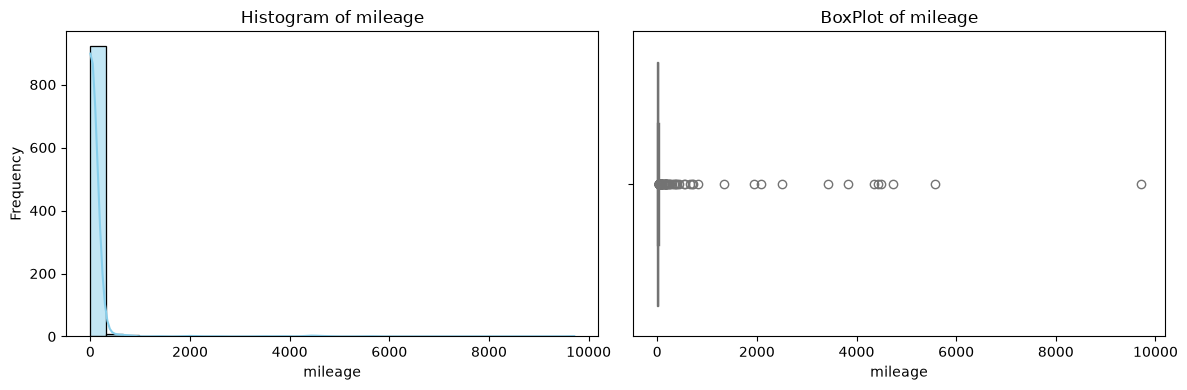

In [5]:
plot_hist_box(df['mileage'])

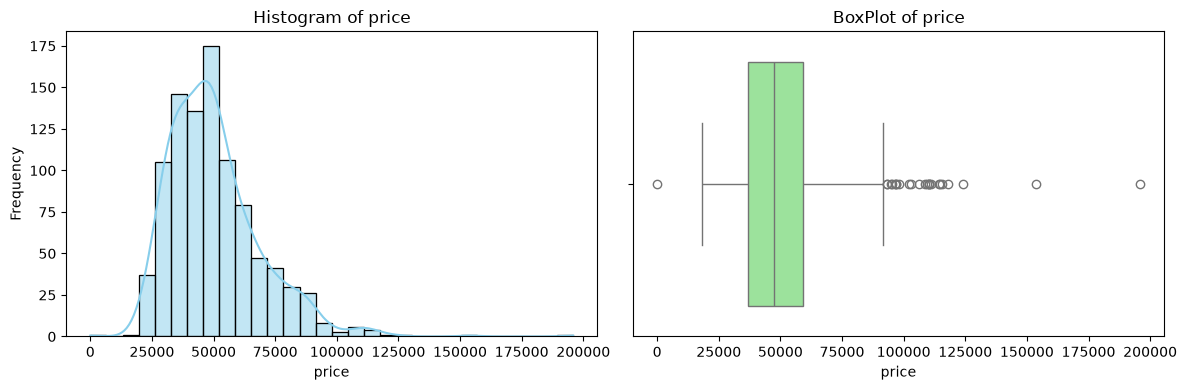

In [6]:
plot_hist_box(df['price'])

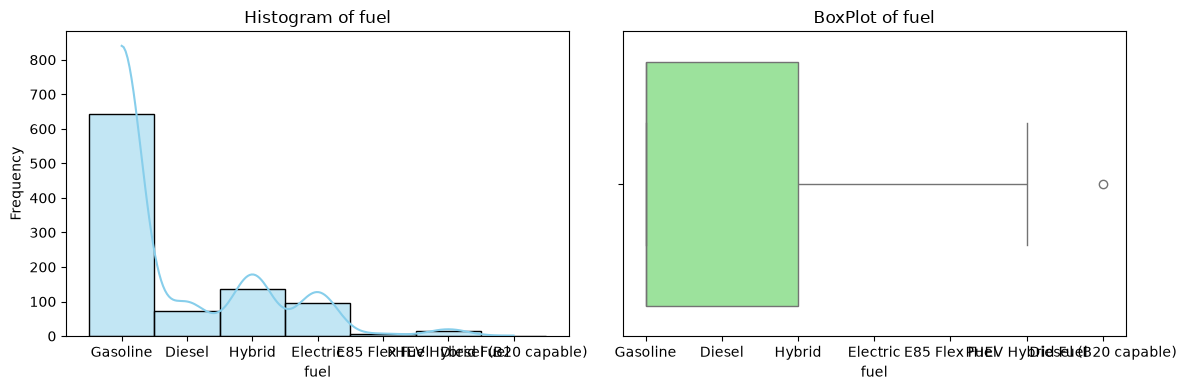

In [7]:
plot_hist_box(df['fuel'])

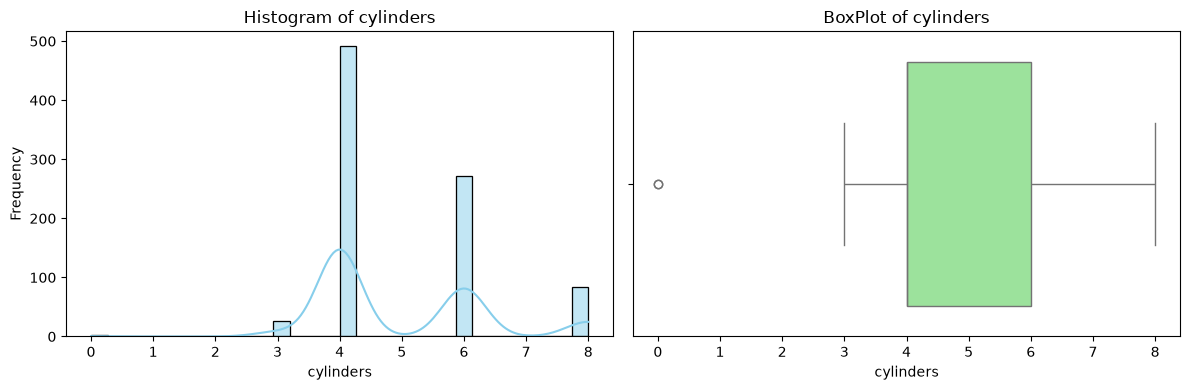

In [8]:
plot_hist_box(df['cylinders'])

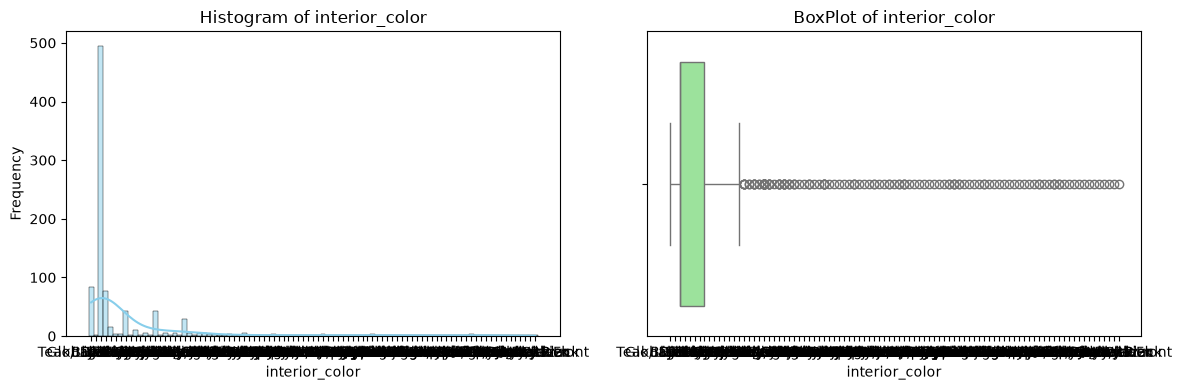

In [9]:
plot_hist_box(df['interior_color'])

# Handling Null Values
1. milage 
2. Price 
3. Fuel 
4. cylinders 
5. Interior_color
6. doors
7. Exterior_color

In [10]:
#Mileage 
df['mileage'] =df['mileage'].fillna(df['mileage'].median())
#Price
data = df.dropna(subset=['price'])
#fuel [Categorical data]
data['fuel'] = data['fuel'].fillna(data['fuel'].mode()[0])

In [11]:
data.groupby('make')['cylinders'].value_counts().reset_index(name='count')

,make,cylinders,count
0,Acura,6.0,11
1,Acura,0.0,1
2,Audi,4.0,8
3,Audi,6.0,1
4,BMW,6.0,5
5,BMW,4.0,2
6,BMW,8.0,1
7,Buick,3.0,4
8,Buick,4.0,2
9,Buick,6.0,1


In [12]:
# Cylinders
cylinder_mode_per_make = data.groupby('make')['cylinders'].apply(lambda x :x.mode()).droplevel(level=None).to_dict()
cylinder_mode_per_make
data['cylinders'] = data['cylinders'].fillna(data['make'].map(cylinder_mode_per_make))
data['cylinders'] = data['cylinders'].fillna(data['make'].map(cylinder_mode_per_make)).fillna(4)

In [13]:
#Interior color 
data['interior_color'] = data['interior_color'].fillna(data['interior_color'].mode()[0])
#doors 
data['doors'] = data['doors'].fillna(data['doors'].mode()[0])
#Exterior_color
data['exterior_color'] = data['exterior_color'].fillna(data['exterior_color'].mode()[0])

In [14]:
# Drop sum columns from data 
data = data.dropna(subset=['transmission','trim','body','engine'])
data.shape

(947, 17)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'Jeep'),
  Text(1, 0, 'GMC'),
  Text(2, 0, 'Dodge'),
  Text(3, 0, 'RAM'),
  Text(4, 0, 'Nissan'),
  Text(5, 0, 'Ford'),
  Text(6, 0, 'Hyundai'),
  Text(7, 0, 'Chevrolet'),
  Text(8, 0, 'Volkswagen'),
  Text(9, 0, 'Chrysler'),
  Text(10, 0, 'Kia'),
  Text(11, 0, 'Mazda'),
  Text(12, 0, 'Acura'),
  Text(13, 0, 'Subaru'),
  Text(14, 0, 'Audi'),
  Text(15, 0, 'BMW'),
  Text(16, 0, 'Toyota'),
  Text(17, 0, 'Buick'),
  Text(18, 0, 'Mercedes-Benz'),
  Text(19, 0, 'Honda'),
  Text(20, 0, 'Lincoln'),
  Text(21, 0, 'Cadillac'),
  Text(22, 0, 'INFINITI'),
  Text(23, 0, 'Lexus'),
  Text(24, 0, 'Land Rover'),
  Text(25, 0, 'Volvo'),
  Text(26, 0, 'Genesis'),
  Text(27, 0, 'Jaguar')])

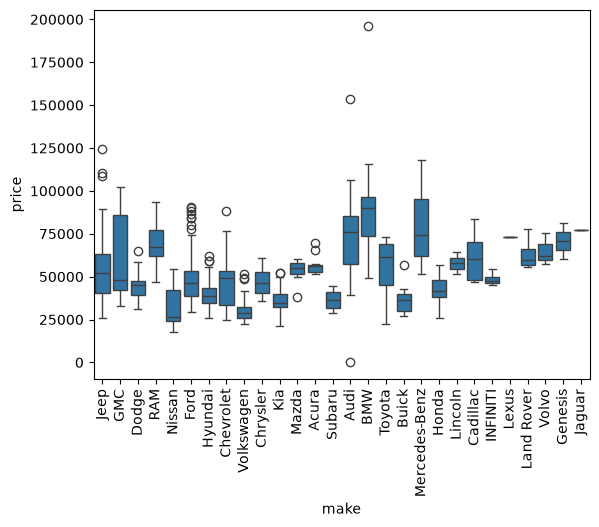

In [15]:
sns.boxplot(x='make',y='price',data=data)
plt.xticks(rotation=90)

In [16]:
data.drop(columns = ['name','description','exterior_color','interior_color'],inplace=True)
data.head(3)

,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain
0,Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,Four-wheel Drive
1,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Four-wheel Drive
2,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Four-wheel Drive


In [17]:
#splitting data by using variables 
x = data.drop(columns='price')
y = data['price']

In [27]:
x.head(2)

,make,model,year,engine,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain
0,Jeep,Wagoneer,2024,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,Four-wheel Drive
1,Jeep,Grand Cherokee,2024,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Four-wheel Drive


In [18]:
y.head(2)

0    74600.0
1    50170.0
Name: price, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,shuffle=True,random_state=42)
print(f"The X train Shape are ==> {x_train.shape}")
print(f"The X Test Shape are ==> {x_test.shape}")

The X train Shape are ==> (757, 12)
The X Test Shape are ==> (190, 12)


In [20]:
x_train.head(3)

,make,model,year,engine,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain
111,Hyundai,Tucson Hybrid,2024,16V GDI DOHC Turbo Hybrid,4.0,Hybrid,5.0,6-Speed Automatic,SEL Convenience,SUV,4.0,All-wheel Drive
78,RAM,3500,2024,24V DDI OHV Turbo Diesel,6.0,Diesel,13.0,Automatic,Tradesman,Pickup Truck,4.0,Four-wheel Drive
578,Chevrolet,Equinox,2024,"4 gasoline direct injection, DOHC, variable va...",4.0,Gasoline,3.0,Automatic,LS,SUV,4.0,All-wheel Drive


In [21]:
x_test.head(3)

,make,model,year,engine,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain
620,Hyundai,Kona,2024,16V MPFI DOHC,4.0,Gasoline,1.0,Automatic CVT,SEL,SUV,4.0,All-wheel Drive
986,Jeep,Grand Cherokee 4xe,2024,16V GDI DOHC Turbo Hybrid,4.0,Hybrid,29.0,8-Speed Automatic,Trailhawk,SUV,4.0,Four-wheel Drive
141,Mazda,CX-90 PHEV,2024,"TIV-G 2.5L I-4 gasoline direct injection, DOHC...",4.0,Gasoline,33.0,Automatic,Base,SUV,4.0,All-wheel Drive


In [22]:
# Check Categorrical columns 
categorical_columns = x_train.select_dtypes(include='object').columns.tolist()
categorical_columns

C:\Users\Alhou\AppData\Local\Temp\ipykernel_10272\3583076664.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x_train.select_dtypes(include='object').columns.tolist()


['make',
 'model',
 'engine',
 'fuel',
 'transmission',
 'trim',
 'body',
 'drivetrain']

In [23]:
# Check unique values 
for col in categorical_columns:
    print(col)
    print(x_train[col].value_counts())
    print("======="*20)

make
make
Jeep             151
Hyundai          101
Dodge             78
Ford              67
RAM               56
Chevrolet         42
Kia               41
Nissan            31
Mazda             28
Volkswagen        27
Mercedes-Benz     21
BMW               16
Honda             15
GMC               15
Audi              12
Cadillac           9
Chrysler           8
Subaru             8
Acura              7
Buick              6
Toyota             5
INFINITI           3
Land Rover         3
Volvo              2
Lincoln            2
Genesis            2
Lexus              1
Name: count, dtype: int64
model
model
Hornet             48
3500               37
Compass            34
Tucson Hybrid      26
Durango            25
                   ..
SQ8 e-tron          1
Ranger              1
Discovery Sport     1
AMG GLE 53          1
Sonata              1
Name: count, Length: 140, dtype: int64
engine
engine
16V GDI DOHC Turbo                                           98
c                         

In [27]:
from sklearn.preprocessing import OneHotEncoder
oht_dervertrain = OneHotEncoder(sparse_output=False)
encoded_values=oht_dervertrain.fit_transform(x_train[['drivetrain']])

* To show Features Names after apply One Hot encoding

In [28]:
encoded_cols = oht_dervertrain.get_feature_names_out().tolist()
encoded_cols

['drivetrain_All-wheel Drive',
 'drivetrain_Four-wheel Drive',
 'drivetrain_Front-wheel Drive',
 'drivetrain_Rear-wheel Drive']

In [29]:
# Convert derive train column to DataFrame
encoded_df = pd.DataFrame(data=encoded_values,columns=encoded_cols,index=x_train.index)
encoded_df.head(3)

,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive
111,1.0,0.0,0.0,0.0
78,0.0,1.0,0.0,0.0
578,1.0,0.0,0.0,0.0


In [30]:
# Concatenate the encoded DataFrame with the original x_train DataFrame
x_train= pd.concat([x_train,encoded_df],axis=1)
x_train.head(3)

,make,model,year,engine,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive
111,Hyundai,Tucson Hybrid,2024,16V GDI DOHC Turbo Hybrid,4.0,Hybrid,5.0,6-Speed Automatic,SEL Convenience,SUV,4.0,All-wheel Drive,1.0,0.0,0.0,0.0
78,RAM,3500,2024,24V DDI OHV Turbo Diesel,6.0,Diesel,13.0,Automatic,Tradesman,Pickup Truck,4.0,Four-wheel Drive,0.0,1.0,0.0,0.0
578,Chevrolet,Equinox,2024,"4 gasoline direct injection, DOHC, variable va...",4.0,Gasoline,3.0,Automatic,LS,SUV,4.0,All-wheel Drive,1.0,0.0,0.0,0.0


In [31]:
#After That we will drop the original column from the x_train DataFrame
x_train.drop(columns=['drivetrain'],inplace=True)
x_train.head(3)

,make,model,year,engine,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive
111,Hyundai,Tucson Hybrid,2024,16V GDI DOHC Turbo Hybrid,4.0,Hybrid,5.0,6-Speed Automatic,SEL Convenience,SUV,4.0,1.0,0.0,0.0,0.0
78,RAM,3500,2024,24V DDI OHV Turbo Diesel,6.0,Diesel,13.0,Automatic,Tradesman,Pickup Truck,4.0,0.0,1.0,0.0,0.0
578,Chevrolet,Equinox,2024,"4 gasoline direct injection, DOHC, variable va...",4.0,Gasoline,3.0,Automatic,LS,SUV,4.0,1.0,0.0,0.0,0.0


### 📌 LabelEncoder vs OrdinalEncoder & When to Use Each
| Feature                | **LabelEncoder**                      | **OrdinalEncoder**                              |
| ---------------------- | ------------------------------------- | ----------------------------------------------- |
| Input                  | **1D vector** (e.g., a single column) | **2D array/DataFrame** (e.g., multiple columns) |
| Output                 | 1D array of integers                  | 2D array of integers                            |
| Use case               | Encode **target variables (labels)**  | Encode **categorical features (input X)**       |
| Handles multiple cols  | ❌ No — only 1 column                  | ✅ Yes                                           |
| Returns ordinal values | ✅ Yes                                 | ✅ Yes                                           |
| Inverse transform      | ✅ Yes                                 | ✅ Yes                                           |
| Commonly used for      | Classification target (`y`)           | Features (`X`) with categories                  |


# After drop drivetrain columns

In [33]:
categorical_columns = x_train.select_dtypes(include='object').columns.tolist()
categorical_columns

C:\Users\Alhou\AppData\Local\Temp\ipykernel_10272\1992550152.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x_train.select_dtypes(include='object').columns.tolist()


['make', 'model', 'engine', 'fuel', 'transmission', 'trim', 'body']

In [34]:
# Check fuel column unique values
x_train['fuel'].value_counts()

fuel
Gasoline            505
Hybrid              107
Electric             77
Diesel               54
PHEV Hybrid Fuel     12
E85 Flex Fuel         2
Name: count, dtype: int64

In [36]:
# Check body column unique values
x_train['body'].value_counts()

body
SUV              535
Pickup Truck     119
Sedan             56
Cargo Van         26
Hatchback         10
Passenger Van      9
Minivan            1
Convertible        1
Name: count, dtype: int64

In [37]:
x_train['make'].value_counts()

make
Jeep             151
Hyundai          101
Dodge             78
Ford              67
RAM               56
Chevrolet         42
Kia               41
Nissan            31
Mazda             28
Volkswagen        27
Mercedes-Benz     21
BMW               16
Honda             15
GMC               15
Audi              12
Cadillac           9
Chrysler           8
Subaru             8
Acura              7
Buick              6
Toyota             5
INFINITI           3
Land Rover         3
Volvo              2
Lincoln            2
Genesis            2
Lexus              1
Name: count, dtype: int64

# Apply oridnal encoding for this columns

In [44]:
from sklearn.preprocessing import OrdinalEncoder
columns_encoder = OrdinalEncoder()
#columns_encoder.fit_transform(x_train[['fuel','body','make']])

In [45]:
# Check x_train data 
x_train[['body','fuel','make']].head(3)

,body,fuel,make
111,SUV,Hybrid,Hyundai
78,Pickup Truck,Diesel,RAM
578,SUV,Gasoline,Chevrolet


# Apply Ordinal Encoding on x_train data

In [48]:
x_train[['body','fuel','make']] =columns_encoder.fit_transform(x_train[['body','fuel','make']])
x_train[['body','fuel','make']].head(3)

,body,fuel,make
111,6.0,4.0,12.0
78,5.0,0.0,22.0
578,6.0,3.0,5.0


In [50]:
for col,categories in zip(['fuel','body','make'],columns_encoder.categories_):
    print(f"Column : {col} \n Categories : {categories}\n")
    for i , category in enumerate(categories):
        print(f"{category} is encoded as ==> {i}")
    print("\n")

Column : fuel 
 Categories : ['Cargo Van' 'Convertible' 'Hatchback' 'Minivan' 'Passenger Van'
 'Pickup Truck' 'SUV' 'Sedan']

Cargo Van is encoded as ==> 0
Convertible is encoded as ==> 1
Hatchback is encoded as ==> 2
Minivan is encoded as ==> 3
Passenger Van is encoded as ==> 4
Pickup Truck is encoded as ==> 5
SUV is encoded as ==> 6
Sedan is encoded as ==> 7


Column : body 
 Categories : ['Diesel' 'E85 Flex Fuel' 'Electric' 'Gasoline' 'Hybrid'
 'PHEV Hybrid Fuel']

Diesel is encoded as ==> 0
E85 Flex Fuel is encoded as ==> 1
Electric is encoded as ==> 2
Gasoline is encoded as ==> 3
Hybrid is encoded as ==> 4
PHEV Hybrid Fuel is encoded as ==> 5


Column : make 
 Categories : ['Acura' 'Audi' 'BMW' 'Buick' 'Cadillac' 'Chevrolet' 'Chrysler' 'Dodge'
 'Ford' 'GMC' 'Genesis' 'Honda' 'Hyundai' 'INFINITI' 'Jeep' 'Kia'
 'Land Rover' 'Lexus' 'Lincoln' 'Mazda' 'Mercedes-Benz' 'Nissan' 'RAM'
 'Subaru' 'Toyota' 'Volkswagen' 'Volvo']

Acura is encoded as ==> 0
Audi is encoded as ==> 1
BMW is enco

<Axes: xlabel='price', ylabel='Density'>

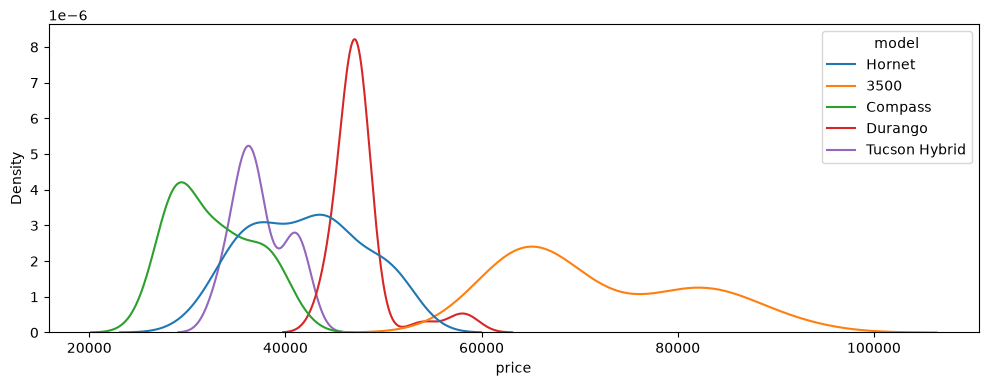

In [52]:
# Check columns effects on the price column 
plt.figure(figsize=(12,4))
#sns.kdeplot(data=data,x='price',hue='model',fill=True,alpha=0.5)
sns.kdeplot(data=data,x='price',hue='model',hue_order=data['model'].value_counts().index[:5])

In [53]:
# Check the number of unique values for model column
data['model'].nunique()

151

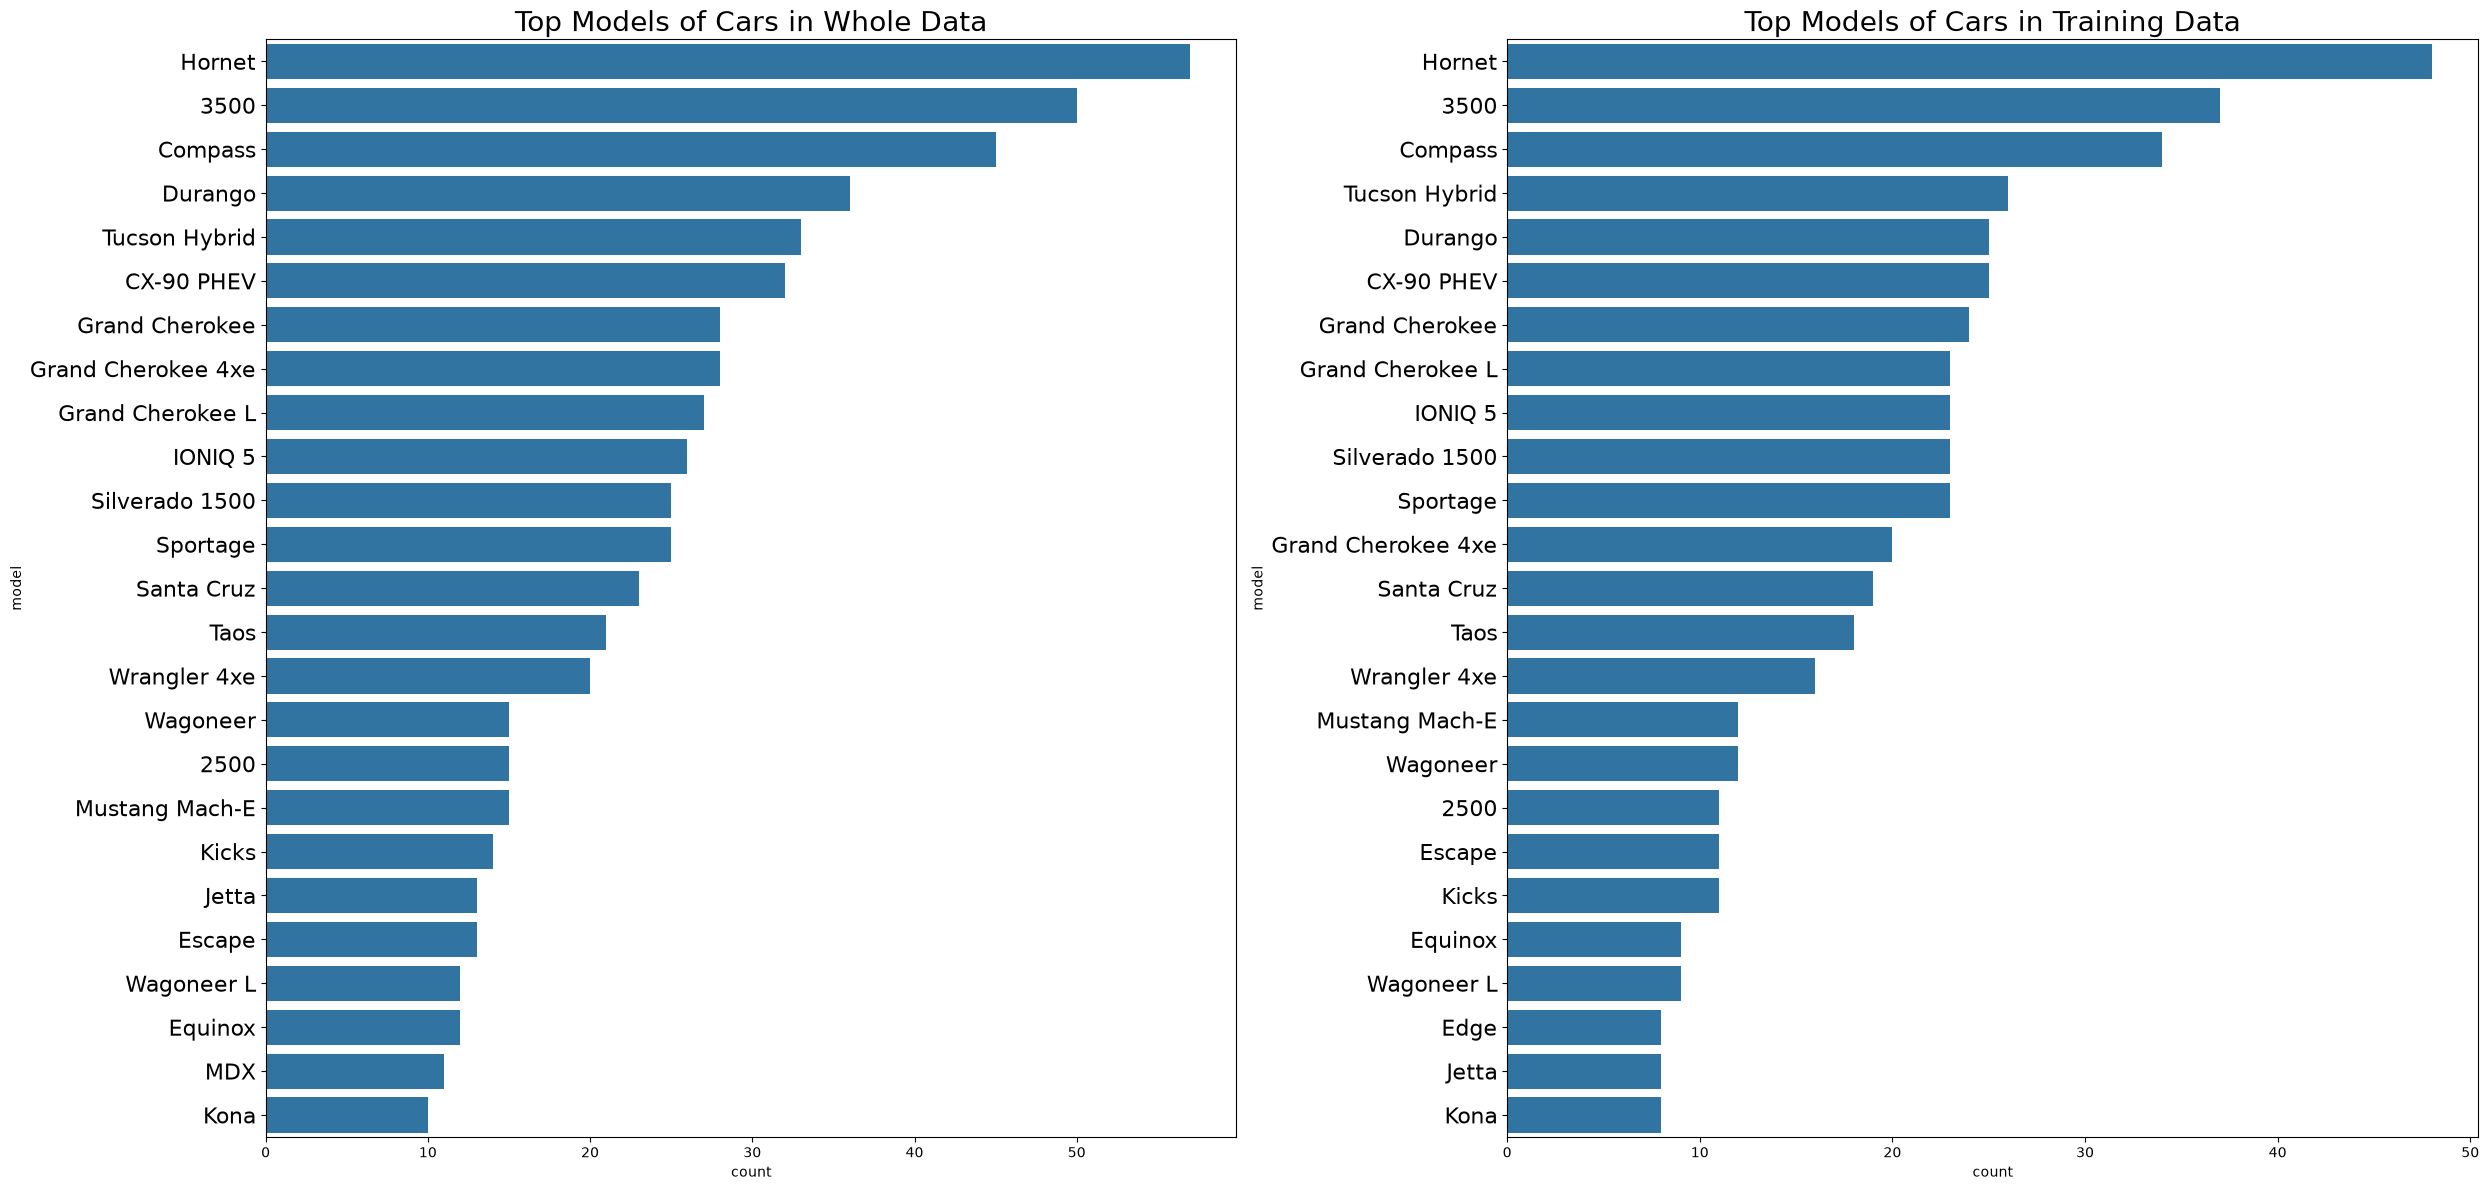

In [55]:
plt.figure(figsize=(25, 12))

# First subplot
plt.subplot(1, 2, 1)
sns.countplot(data=data, y='model', order=data['model'].value_counts().index[:25])
plt.yticks(fontsize=16)
plt.title('Top Models of Cars in Whole Data', fontsize=20)

# Second subplot
plt.subplot(1, 2, 2)
sns.countplot(data=x_train, y='model', order=x_train['model'].value_counts().index[:25])
plt.yticks(fontsize=16)
plt.title('Top Models of Cars in Training Data', fontsize=20)

plt.tight_layout();

In [60]:
top_models= x_train['model'].value_counts().nlargest(25).index

In [61]:
x_train['model']=x_train['model'].where(x_train['model'].isin(top_models),'other')
x_train['model']

111       Tucson Hybrid
78                 3500
578             Equinox
893               other
84     Grand Cherokee L
             ...       
108             Compass
278          CX-90 PHEV
911            Sportage
455                2500
104      Silverado 1500
Name: model, Length: 757, dtype: object

# `Task` 

# Apply one hot encoding for model column

In [66]:
x_train['model'] = x_train['model'].astype(str)
oht_model = OneHotEncoder(sparse_output=False)
encoded_values = oht_model.fit_transform(x_train[['model']])
encoded_cols = oht_model.get_feature_names_out().tolist()
#Convert model column to DataFrame
encoded_df = pd.DataFrame(data=encoded_values,columns=encoded_cols,index=x_train.index)
#Concatenate the encoded DataFrame with the original x_train DataFrame
x_train = pd.concat([x_train,encoded_df],axis=1)
#drop the original model column from the x_train DataFrame
x_train.drop(columns=['model'], inplace=True)
x_train.head(3)

,make,year,engine,cylinders,fuel,mileage,transmission,trim,body,doors,...,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other
111,12.0,2024,16V GDI DOHC Turbo Hybrid,4.0,4.0,5.0,6-Speed Automatic,SEL Convenience,6.0,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
78,22.0,2024,24V DDI OHV Turbo Diesel,6.0,0.0,13.0,Automatic,Tradesman,5.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
578,5.0,2024,"4 gasoline direct injection, DOHC, variable va...",4.0,3.0,3.0,Automatic,LS,6.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Apply Encoding for engine column

In [67]:
x_train['engine'].unique()

<StringArray>
[                                '16V GDI DOHC Turbo Hybrid',
                                  '24V DDI OHV Turbo Diesel',
 '4 gasoline direct injection, DOHC, variable valve control',
      'd>\n\n    \n    <dt>VIN</dt>\n     7FARS4H71SE000866',
                                                       'OHV',
 'ce 5.6L V-8 gasoline direct injection, DOHC, variable val',
                                       '16V GDI DOHC Hybrid',
                                                         'c',
                                        '16V PDI DOHC Turbo',
  '6.2L V-8 gasoline direct injection, variable valve contr',
                                               '16V GDI OHV',
 'gasoline direct injection, DOHC, intercooled turbo, premi',
                                             '24V MPFI DOHC',
                                              '16V MPFI OHV',
 'DOHC, D-CVVT variable valve control, regular unleaded, en',
                           'oled Turbo Diesel I-6 6.7 L/

In [68]:
# Apply feature engineering 
x_train['engine']= x_train['engine'].astype(str).str.lower() # First convert data to lowercase 
# Extract features from engine column
x_train['is_turbo'] = x_train['engine'].apply(lambda x:1 if 'turbo' in x or 'ecoboost' in x else 0)
x_train['is_hybrid'] = x_train['engine'].apply(lambda x:1 if 'hybrid' in x else 0)
x_train['is_diesel'] = x_train['engine'].apply(lambda x:1 if 'diesel' in x else 0)

#Extract the valve type from engine column
def get_valve_type(text):
    if 'dohc' in text: return 'DOHC'
    if 'ohv' in text: return 'OHV'
    if 'sohc' in text: return 'SOHC'
    return 'Other' # For corrupted texts and VIN codes
x_train['valve_type'] = x_train['engine'].apply(get_valve_type)

# After apply feature engineering and preprocessing for engine column , and extract features

In [69]:
oht_valve = OneHotEncoder(sparse_output=False,drop='first')
encoded_vaules = oht_valve.fit_transform(x_train[['valve_type']])
encoded_cols = oht_valve.get_feature_names_out().tolist()
# Convert the encoded values to a DataFrame
encoded_df = pd.DataFrame(data=encoded_vaules,columns=encoded_cols,index=x_train.index)
# Concatenate the encoded DataFrame with the original x_train DataFrame
x_train = pd.concat([x_train,encoded_df],axis=1)
# Drop the original engine column and valve_type column
x_train.drop(columns=['engine','valve_type'],inplace=True)
print(x_train[['is_turbo', 'is_hybrid', 'is_diesel'] + encoded_cols].head())
x_train.head(3)

     is_turbo  is_hybrid  is_diesel  valve_type_OHV  valve_type_Other  \
111         1          1          0             0.0               0.0   
78          1          0          1             1.0               0.0   
578         0          0          0             0.0               0.0   
893         0          0          0             0.0               1.0   
84          0          0          0             1.0               0.0   

     valve_type_SOHC  
111              0.0  
78               0.0  
578              0.0  
893              0.0  
84               0.0  


,make,year,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain_All-wheel Drive,...,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other,is_turbo,is_hybrid,is_diesel,valve_type_OHV,valve_type_Other,valve_type_SOHC
111,12.0,2024,4.0,4.0,5.0,6-Speed Automatic,SEL Convenience,6.0,4.0,1.0,...,0.0,0.0,0.0,0.0,1,1,0,0.0,0.0,0.0
78,22.0,2024,6.0,0.0,13.0,Automatic,Tradesman,5.0,4.0,0.0,...,0.0,0.0,0.0,0.0,1,0,1,1.0,0.0,0.0
578,5.0,2024,4.0,3.0,3.0,Automatic,LS,6.0,4.0,1.0,...,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0


# `Task`

In [70]:
x_train['transmission'] = x_train['transmission'].astype(str).str.lower()
x_train['trim'] = x_train['trim'].astype(str).str.lower()
#=========================================================================
x_train['is_automatic'] = x_train['transmission'].apply(lambda x:1 if 'auto' in x else 0)
x_train['is_cvt'] = x_train['transmission'].apply(lambda x:1 if 'cvt' in x else 0)
x_train['num_speeds'] = x_train['transmission'].str.extract(r'(\d+)\s*speed').astype(float)
#========================================================================================
x_train['trim_awd'] = x_train['trim'].apply(lambda x:1 if 'awd' in x or '4wd' in x else 0)
#==========================================================================================
oht_trim = OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore')
encoded_trim_values = oht_trim.fit_transform(x_train[['trim']])
encoded_trim_cols = oht_trim.get_feature_names_out().tolist()
# Convert the encoded values to a DataFrame
encoded_trim_df = pd.DataFrame(data=encoded_trim_values,columns=encoded_trim_cols,index=x_train.index)
# Concatenate the encoded DataFrame with the original x_train DataFrame
x_train = pd.concat([x_train,encoded_trim_df],axis=1)
# Drop the original trim column
x_train.drop(columns=['trim','transmission'],inplace=True)
print(x_train[['is_automatic', 'is_cvt', 'num_speeds', 'trim_awd'] + encoded_trim_cols].head())

     is_automatic  is_cvt  num_speeds  trim_awd  trim_1.4t se  trim_1.5t s  \
111             1       0         NaN         0           0.0          0.0   
78              1       0         NaN         0           0.0          0.0   
578             1       0         NaN         0           0.0          0.0   
893             1       1         NaN         0           0.0          0.0   
84              1       0         NaN         0           0.0          0.0   

     trim_1.5t se  trim_1.5t sel  trim_1.6 sr  trim_1.6 sv  ...  trim_wt  \
111           0.0            0.0          0.0          0.0  ...      0.0   
78            0.0            0.0          0.0          0.0  ...      0.0   
578           0.0            0.0          0.0          0.0  ...      0.0   
893           0.0            0.0          0.0          0.0  ...      0.0   
84            0.0            0.0          0.0          0.0  ...      0.0   

     trim_x-line  trim_x-pro prestige  trim_xdrive40  trim_xdrive40i  trim

In [71]:
x_train.head(5)

,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,...,trim_wt,trim_x-line,trim_x-pro prestige,trim_xdrive40,trim_xdrive40i,trim_xl,trim_xlt,trim_xrt,trim_xse,trim_zr2
111,12.0,2024,4.0,4.0,5.0,6.0,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78,22.0,2024,6.0,0.0,13.0,5.0,4.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
578,5.0,2024,4.0,3.0,3.0,6.0,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
893,11.0,2025,4.0,3.0,0.0,6.0,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84,14.0,2024,6.0,3.0,8.0,6.0,4.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


C:\Users\Alhou\AppData\Local\Temp\ipykernel_10272\4195889561.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_percentages.values, y=null_percentages.index, palette='Reds_r')


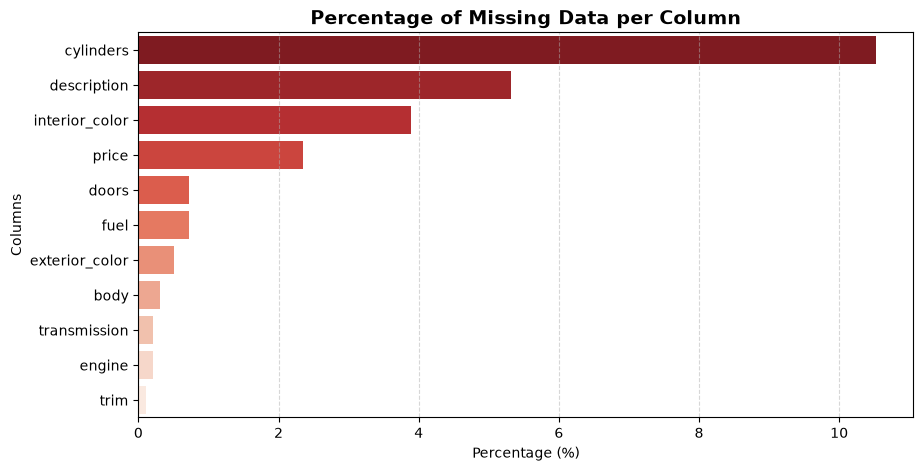

In [72]:
null_percentages = df.isnull().sum().sort_values(ascending=False) * 100 / len(df)
null_percentages = null_percentages[null_percentages > 0] # عرض الأعمدة التي تحتوي على قيم مفقودة فقط

plt.figure(figsize=(10, 5))
sns.barplot(x=null_percentages.values, y=null_percentages.index, palette='Reds_r')
plt.title('Percentage of Missing Data per Column', fontsize=14, fontweight='bold')
plt.xlabel('Percentage (%)')
plt.ylabel('Columns')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

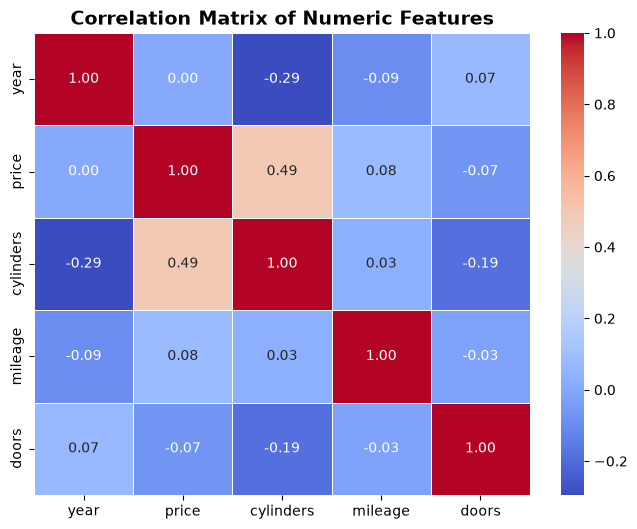

In [73]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.show()

C:\Users\Alhou\AppData\Local\Temp\ipykernel_10272\3245102920.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_makes, x='make', y='price', palette='Set3')


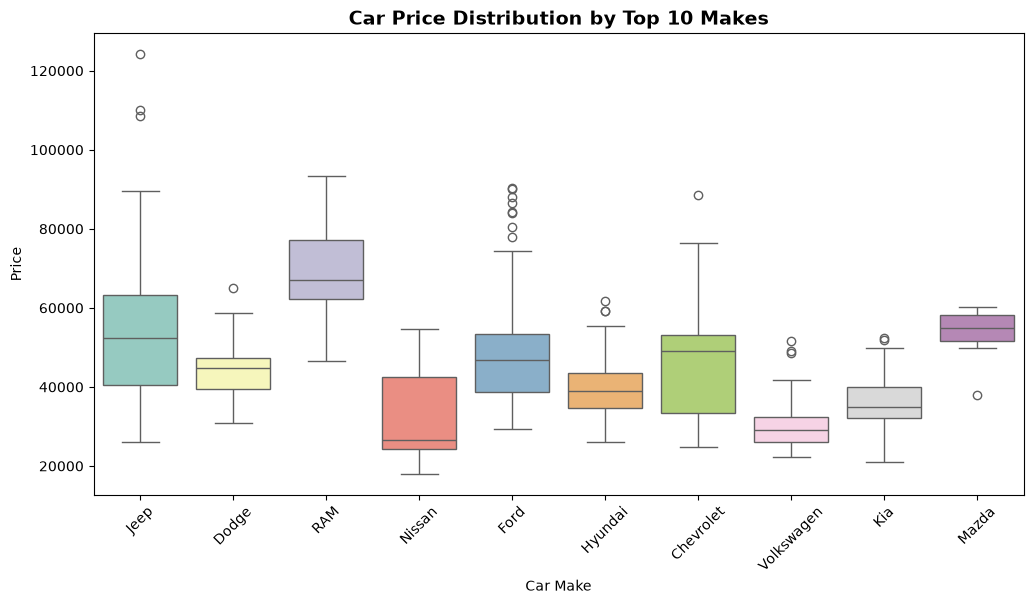

In [74]:
top_makes = df['make'].value_counts().nlargest(10).index
df_top_makes = df[df['make'].isin(top_makes)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_makes, x='make', y='price', palette='Set3')
plt.title('Car Price Distribution by Top 10 Makes', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Car Make')
plt.ylabel('Price')
plt.show()

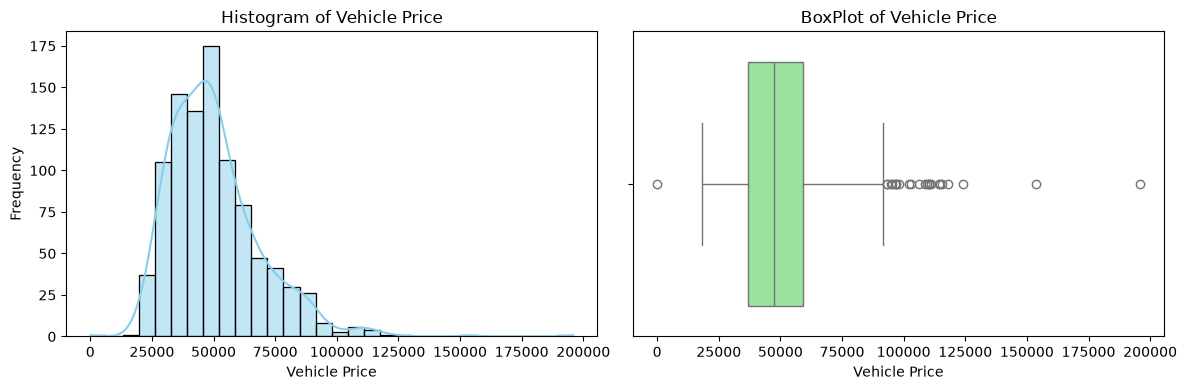

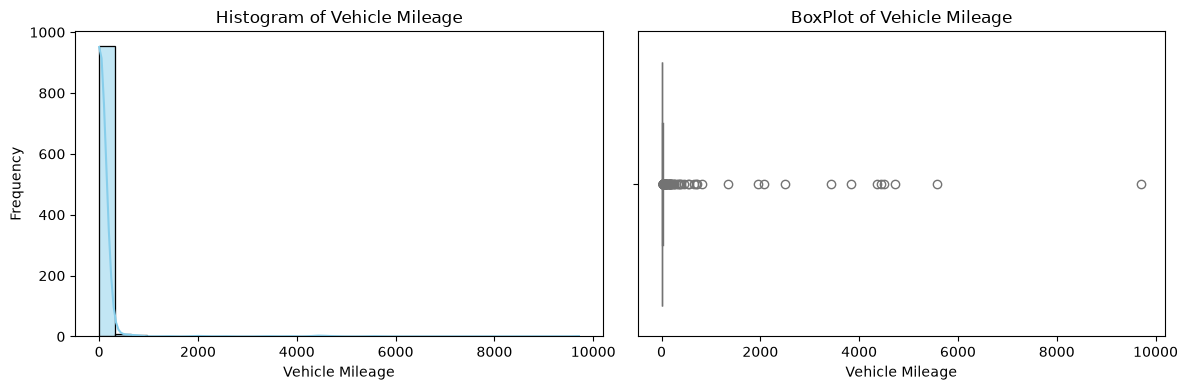

In [75]:
plot_hist_box(df['price'], 'Vehicle Price')
plot_hist_box(df['mileage'].dropna(), 'Vehicle Mileage')